# NB2: Validating the Performance of Regional Climate Model Simulations (before and after Bias Correction)

## 1. Introduction
Regional Climate Models (RCMs) are one of the main tools used to investigate the impacts of climate change at regional and local scales. Unlike global climate models (GCMs), RCMs provide much higher spatial resolution, allowing a better representation of topography, coastlines and regional atmospheric processes.

Despite these advantages, RCM simulations usually exhibit systematic biases when compared with observational or reanalysis datasets. These biases arise from several sources, including imperfections in the driving GCM, limitations of the RCM itself and unresolved physical processes.

Because many climate impact studies require realistic representations of temperature and precipitation, it is common practice to apply bias correction methods before using RCM simluations.

This notebook introduces a complete validation workflow for CORDEX-CORE RCM simulations, using ERA5 as reference. Several diagnostics are computed before and after bias correction in order to assess the performance of different correction methods.

### 1.1. Learning Objectives
After completing this notebook, you should be able to

* understand the purpose of climate model validation;
* compare gridded climate datasets;
* compute validation metrics using the climate4R ecosystem;
* interpret model bias and temporal correlation;
* understand the rationale behind bias correction;
* compare different bias correction methods;
* evaluate climate indices before and after bias correction

## 2. Preparing the Working Environment
First, it is necessary to define a few parameters controlling the analysis to be undertaken and load the required libraries.

The climate4R ecosystem provides a collection of packages specifically designed for handling climate data. These packages  (`loadeR`, `transformeR`, `visualizeR`, `downscaleR`, `climate4R.value`) allow users to manipulate both station observations and gridded datasets through a common data structure, making subsequent analyses considerably easier (including temporal and spatial subsetting, regridding, visualization, bias correction and statistical downscaling).

In addition, some extra libraries outside climate4R (`RColorBrewer`, `lattice`, `gridExtra`) are also loaded to facilitate the production of publication-quality figures.

In [1]:
rm(list = ls())

## params ##
dirbase = "/home/jovyan"
dirdata.obs = sprintf("%s/data/obs", dirbase)
dirdata.era5 = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/era5"
dirdata.cordex = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/cordex-core"

#lon = c(60, 80)
#lat = c(22, 38)

#lon = c(66, 75)
#lat = c(24, 35)

lon = c(66, 68)  # small region of study (encompassing Karachi)
lat = c(24, 26)  # small region of study (encompassing Karachi)

## libraries ##
library(loadeR)
library(transformeR)
library(visualizeR)
library(downscaleR)
library(climate4R.value)
library(RColorBrewer)
library(lattice)
library(gridExtra)

## auxiliary functions ##
source(sprintf("%s/notebooks/auxiliary_functions.R", dirbase))

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 2.00 GB

NetCDF Java Library Version: 5.10.0 (Built-On: NA) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from env LOADER_JAVA_CLASSPATH + bundled java package directory: /home/rodri/miniforge3/envs/C4R-pakistan/lib/java/toolsUI.jar:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

downscaleR version 3.3.4 (2023-06-22) is loaded

Please use 'citation("downscaleR")' to cite this package.

Loading required package: VALUE

---------------------------------------------- 
| VALUE version 2.2.4 (2023-06-22) is loaded |
|         http://www.value-cost.eu           |
----------------------------------------------



## 3. Loading ERA5 and CORDEX-CORE Data

The first step consists of loading the two datasets that will be compared throughout the notebook (function `loadGridData()`).

On the one hand, the reference dataset is ERA5, a state-of-the-art atmospheric reanalysis that combines observations and numerical weather prediction through data assimilation.

On the other hand, we will consider simulations produced within the CORDEX-CORE initiative, one of the international coordinated efforts aimed at providing high-resolution regional climate projections. In particular, and for illustrative purposes, we will focus on the REMO2015 RCM, driven by the HadGEM2-ES GCM. Nonetheless, the full workflow described in this notebook could be equally applied to the rest of CORDEX-CORE simulations (e.g. GCM-RCM combinations) available.

Although both datasets describe the same atmospheric variable (daily maximum temperature), they originate from fundamentally different sources. Consequently, some discrepancies are expected and constitute the basis for the validation exercise presented in this notebook.

To alleviate a bit the computational cost of the workflow presented hereafter, the comparison between ERA5 and the CORDEX-CORE simulation (historical scenario) is carried out for the period 1986-2005.

In [2]:
## loading tmax from ERA5 ##
era5 = loadGridData(sprintf("%s/tmax.nc", dirdata.era5),
                     var = "tmax", 
                     lonLim = lon, latLim = lat,
                     years = 1986:2005)
getShape(era5)

[2026-07-17 11:11:29.444001] Opening dataset...

[2026-07-17 11:11:30.24946] The dataset was successfuly opened

[2026-07-17 11:11:30.253843] Defining geo-location parameters

[2026-07-17 11:11:30.292355] Defining time selection parameters

[2026-07-17 11:11:30.418182] Retrieving data subset ...

[2026-07-17 11:11:35.843482] Done



time  lat  lon 
7305    9    9

In [3]:
## loading tmax from CORDEX-CORE ##
# model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "MPI-ESM-MR_RegCM4-7", "NorESM1-M_REMO2015","NorESM1-M_RegCM4-7")
model = c("HadGEM2-ES_REMO2015")
cordex = loadGridData(sprintf("%s/%s_historical_tmax.nc", dirdata.cordex, model),
                     var = "tmax", lonLim = lon, latLim = lat,
                     years = 1986:2005)
getShape(cordex)

[2026-07-17 11:11:36.063184] Opening dataset...

[2026-07-17 11:11:36.292255] The dataset was successfuly opened

[2026-07-17 11:11:36.2979] Defining geo-location parameters

[2026-07-17 11:11:36.32469] Defining time selection parameters

[2026-07-17 11:11:36.402424] Retrieving data subset ...

[2026-07-17 11:11:40.619596] Done



time  lat  lon 
7165    9    9

Noteworthy, all the CORDEX-CORE simulations have been already regridded to the ERA5's regular grid of 0.25º resolution. 

In [4]:
getGrid(era5)
identical(getGrid(era5), getGrid(cordex))

$x
[1] 66 68

$y
[1] 24 26

attr(,"projection")
[1] "LatLonProjection"
attr(,"resX")
[1] 0.25
attr(,"resY")
[1] 0.25

[1] TRUE

# 4. Harmonizing ERA5 and CORDEX-CORE Data

Even if both datasets cover approximately the same years, small differences in temporal coverage may exist because of missing records, different calendars or distinct processing procedures.

For this reason, the first preprocessing step consists of identifying the common temporal period shared by ERA5 and the CORDEX-CORE simulation (function `intersectGrid()`).

In [5]:
era5 = intersectGrid(era5, cordex, type = "temporal", which.return = 1)
getShape(era5)
getShape(cordex)

time  lat  lon 
7165    9    9

time  lat  lon 
7165    9    9

Both ERA5 and CORDEX-CORE store temperature in Kelvin (K). For interpretation and visualization purposes, both datasets are therefore converted from Kelvin to degrees Celsius before proceeding with the analysis.

In [6]:
## converting K to degC ##
era5 = gridArithmetics(era5, 273.15, operator = "-")
cordex = gridArithmetics(cordex, 273.15, operator = "-")

## 5. Validating CORDEX-CORE Data

No climate model is perfect. Therefore, before using it for impact studies, it is necessary to evaluate how realistically it reproduces present-day climate.

Model evaluation serves several purposes:

* identifying systematic biases;
* assessing temporal variability;
* evaluating spatial patterns;
* determining whether the simulations are suitable for a particular application.

The objective of validation is therefore not to determine whether a model is "correct", but rather to understand how it differs from the reference dataset and whether these differences are acceptable for the intended application.

The `climate4R.value` package implements a wide range of validation measures (see the `show.measures()` function).

Different metrics quantify different aspects of model performance.

For example,

* some evaluate temporal agreement;
* others assess spatial similarity;
* some measure systematic bias;
* others compare complete probability distributions.

Throughout this notebook we will progressively introduce several complementary diagnostics.

**Note:** Model evaluation should never rely on a single statistic.

### 5.1 Mean Bias
The simplest diagnostics used in climate model evaluation is the mean bias.

The bias is defined as the difference between the model climatology and the reference climatology. Positive values indicate systematic overestimation. Negative values indicate systematic underestimation.

Spatial bias maps are particularly useful because they reveal whether systematic errors are concentrated in specific geographical regions or whether they affect the entire domain.

[2026-07-17 11:11:41.276698] - Computing climatology...

[2026-07-17 11:11:41.287942] - Done.

[2026-07-17 11:11:41.295566] - Computing climatology...

[2026-07-17 11:11:41.301224] - Done.



time  lat  lon 
   1    9    9

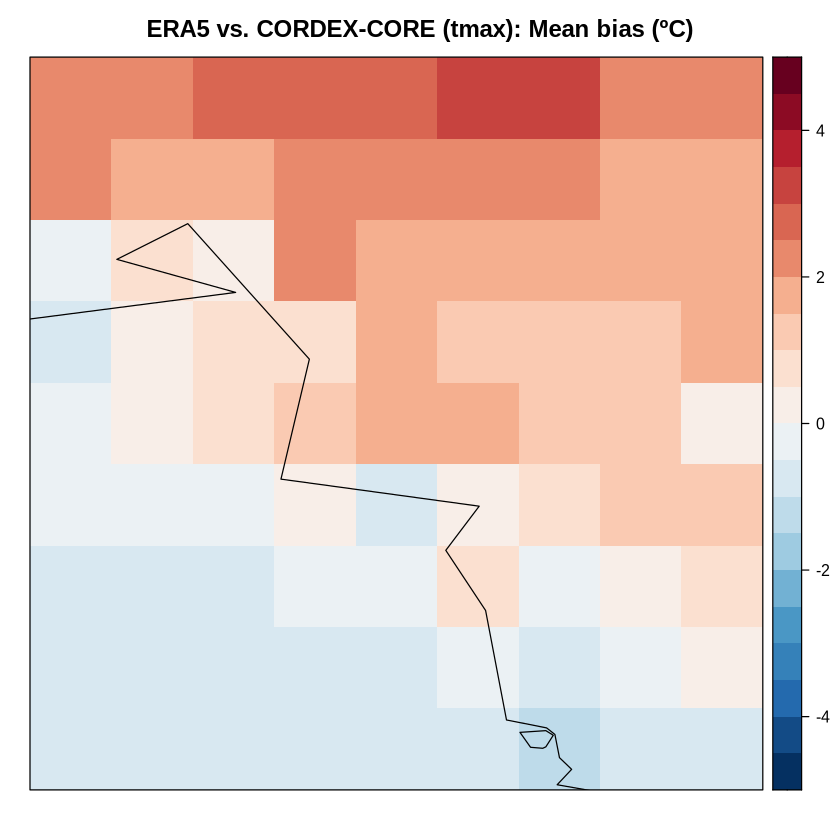

In [7]:
## computing (and plotting) the mean bias between ERA5 and CORDEX-CORE ##
bias = gridArithmetics(climatology(cordex), climatology(era5), 
                       operator = "-")
getShape(bias)
spatialPlot(bias, backdrop.theme = "countries",
            main = "ERA5 vs. CORDEX-CORE (tmax): Mean bias (ºC)",
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -5, set.max = 5, at = seq(-5, 5, 0.5))

### 5.2 Daily Correlation

The second validation metric considered here is the daily Pearson correlation coefficient (function `valueMeasure()` from package `climate4r.value`).

Correlation measures how similarly two time series evolve through time. A high correlation indicates that warm and cold periods tend to occur simultaneously in both datasets. Importantly, correlation does not account for model biases.

For example, a model may consistently underestimate temperature by several degrees while still exhibiting an excellent temporal correlation if it correctly reproduces the temporal variability.

,CODE,FUNCTION.CALL,DESCRIPTION
,<chr>,<chr>,<chr>
1,ts.cmIndex,measure.cm(what = CvM),Cramer von Mises Index
2,ts.cmpval,measure.cm(what = pval),Cramer von Mises Index p-value
3,ts.cmksdiff,measure.cm(what = KSdiff),Maximum absolute difference between the distributions
4,ts.rp,measure.cor(method = pearson),Pearson correlation
5,ts.rs,measure.cor(method = spearman),Spearman correlation
6,ts.rocss,measure.rocss(),Roc Skill Score (ROCSS)
7,ts.MAE,measure.mae(),Mean Absolute Error
8,ts.RMSE,measure.rmse(),Root Mean Square Error
9,bias,measure.bias(),Pred-Obs


[2026-07-17 11:11:43.422101] Computing member 1 out of 1

[2026-07-17 11:11:43.745913] Done.



time  lat  lon 
   1    9    9

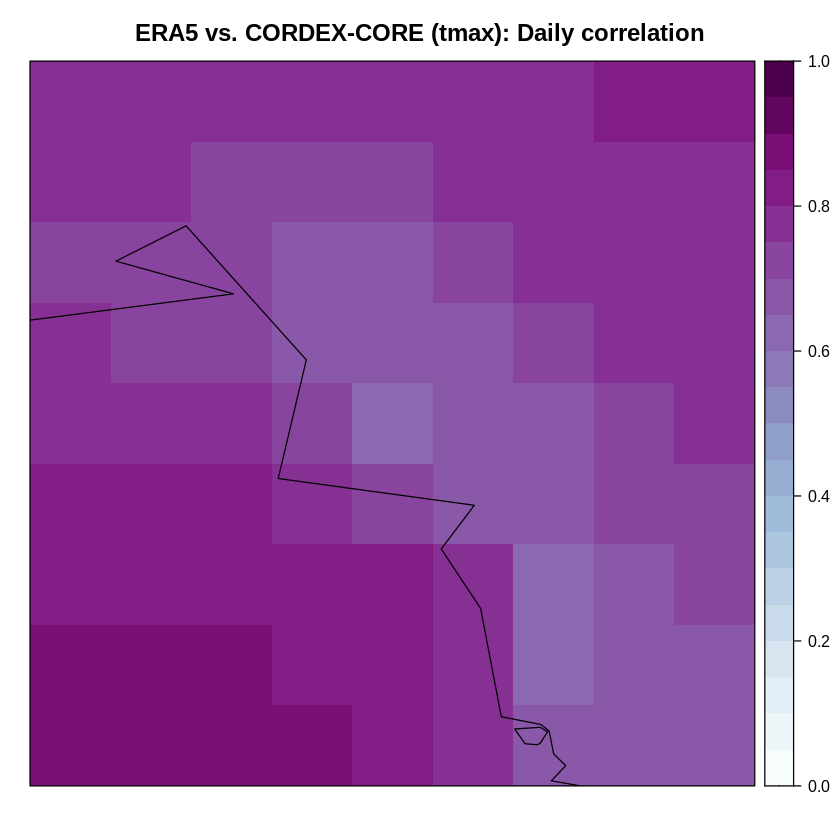

In [8]:
show.measures()  # metrics available in the climate4R.value package

## computing (and plotting) daily correlation between ERA5 and CORDEX-CORE ##
rho = valueMeasure(era5, cordex, measure.code = "ts.rp")
getShape(rho$Measure)
spatialPlot(rho$Measure, backdrop.theme = "countries",
           main = "ERA5 vs. CORDEX-CORE (tmax): Daily correlation",
           color.theme = "BuPu",
           set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

### 5.3 Interannual Correlation

Daily variability is strongly influenced by individual weather systems.

Many climate impact studies, however, focus instead on variations from one year to another.

To investigate this aspect, both datasets are first aggregated into annual means. The correlation is then recomputed using these annual time series.

Because annual averaging filters out much of the short-term variability, interannual correlations often differ substantially from daily correlations. Comparing both diagnostics provides insight into the temporal scales that the model reproduces most successfully.

[2026-07-17 11:11:45.491136] Computing member 1 out of 1

[2026-07-17 11:11:45.977894] Done.



time  lat  lon 
   1    9    9

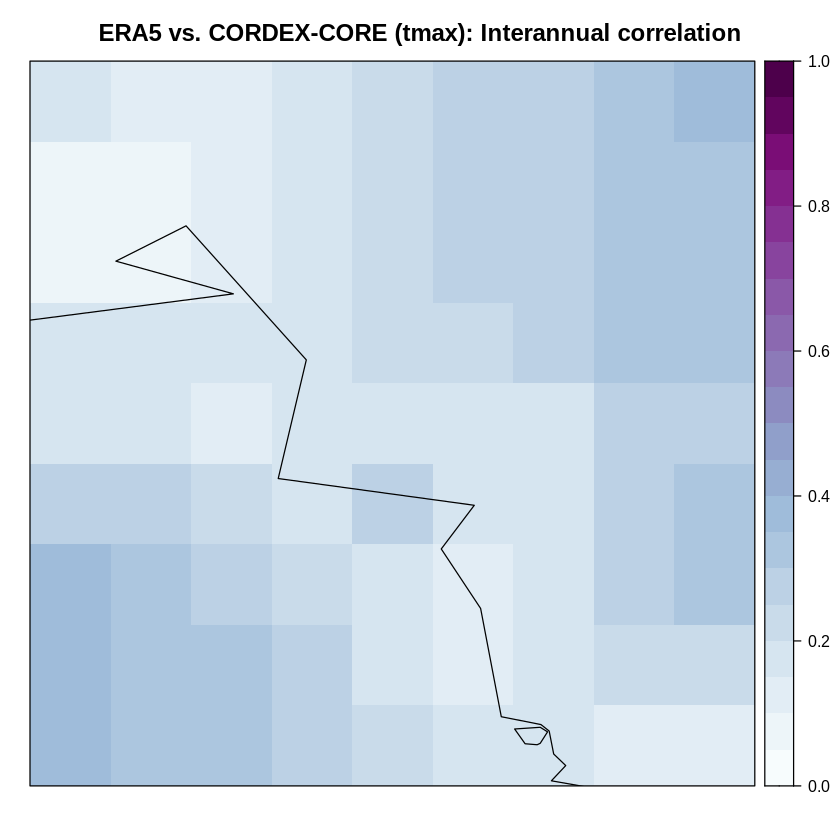

In [9]:
## computing (and plotting) interannual correlation between ERA5 and CORDEX-CORE ##
rho.y = valueMeasure(era5, cordex, measure.code = "ts.rpY")
getShape(rho.y$Measure)
spatialPlot(rho.y$Measure, backdrop.theme = "countries",
            main = "ERA5 vs. CORDEX-CORE (tmax): Interannual correlation",
            color.theme = "BuPu",
            set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

### 5.4 Bias in Extreme Percentiles (P95)
Beyond the mean bias, it is particularly interesting to investigate the bias in extreme temperatures, for instance, the 95th percentile.

[2026-07-17 11:11:47.675817] - Computing climatology...

[2026-07-17 11:11:47.690379] - Done.

[2026-07-17 11:11:47.693656] - Computing climatology...

[2026-07-17 11:11:47.711904] - Done.



time  lat  lon 
   1    9    9

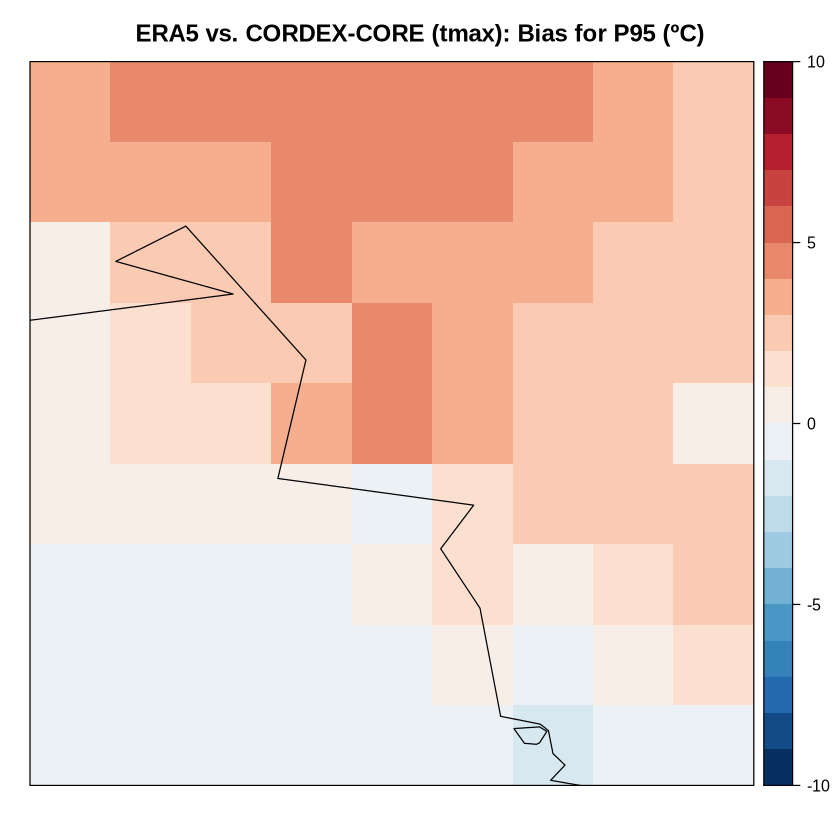

In [10]:
## computing (and plotting) the bias in P95 between ERA5 and CORDEX-CORE ##
p95.era5 = climatology(era5, clim.fun = list(FUN = "quantile", probs = 0.95))
p95.cordex = climatology(cordex, clim.fun = list(FUN = "quantile", probs = 0.95))
bias.p95 = gridArithmetics(p95.cordex, p95.era5, 
                       operator = "-")
getShape(bias.p95)
spatialPlot(bias.p95, backdrop.theme = "countries",
            main = "ERA5 vs. CORDEX-CORE (tmax): Bias for P95 (ºC)",
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -10, set.max = 10, at = seq(-10, 10, 1))

## 6. Bias Correction

Once systematic errors have been identified, the next logical question is whether they can be reduced. This is precisely the objective of bias correction.

Bias correction consists of statistically adjusting model simulations so that their statistical properties resemble those of a reference dataset during a historical calibration period. Typically, these adjustments are subsequently applied to future climate projections under the assumption that model biases remain approximately stationary over time.

Bias correction has become a standard preprocessing step in many climate change impact studies, particularly in agriculture, hydrology, ecology and energy applications.

However, it is important to remember that bias correction does not improve the physical realism of the climate model itself. Instead, it modifies the model output so that it becomes more suitable for downstream applications.

### 6.1 The Scaling Method

In climate4R, a number of bias correction methods (the most widely used in the literature) can be easily applied calling the `biasCorrection()` function from the `downscaleR` package. The simplest one is the Scaling method. 

For temperature variables, Scaling consists of adjusting the mean value (and only the mean) of the simulated series so that it matches the observed climatology.

Because only the average is modified, the method is computationally inexpensive and easy to interpret. However, its simplicity also limits its ability to correct other aspects of the distribution, such as variability or extremes.

**Note:** When the aim is to correct the historical scenario of a climate model, a cross-validation framework must be applied to avoid overfitting (`cross-val` argument). In this notebook, we use a k-fold approach, with k=2. 

In [11]:
## application of the scaling method for bias correction ##
cordex.bc.scaling = biasCorrection(era5, cordex, method = "scaling", 
                                   cross.val = "kfold", folds = 2)
cordex.bc.scaling$Dates$start = as.character(cordex.bc.scaling$Dates$start)  # manually fixing bug with dates after bias correction
cordex.bc.scaling$Dates$end = as.character(cordex.bc.scaling$Dates$end)  # manually fixing bug with dates after bias correction

getShape(cordex.bc.scaling)
cordex.bc.scaling = intersectGrid(era5, cordex.bc.scaling, type = "temporal", which.return = 2)  # alligning dates after bias correction

[2026-07-17 11:11:49.729745] Trying to determine the time zone...

[2026-07-17 11:11:49.731077] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:11:49.850902] Trying to determine the time zone...

[2026-07-17 11:11:49.852691] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:11:50.250132] Trying to determine the time zone...

[2026-07-17 11:11:50.251936] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-07-17 11:11:50.943847] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:11:50.993068] Number of windows considered: 1...

[2026-07-17 11:11:50.999273] Bias-correcting 1 members separately...

[2026-07-17 11:11:51.154064] Done.

Validation 2, 0 remaining

[2026-07-17 11:11:51.722988] Argument precipitation is set as FALSE, please ensure that this matches you

time  lat  lon 
7304    9    9

After applying the bias correction, the first step is to assess whether it has achieved its intended objective.

To evaluate the correction, we repeat exactly the same diagnostics that were previously computed for the raw simulation. Note that  comparing the same diagnostics before and after correction allows for assessing the effectiveness of the bias correction method objectively.

**Note:** Since Scaling only adjusts the mean climatology, we should expect a substantial reduction of the systematic bias. However, other characteristics of the distribution (for example, the bias in extreme percentiles) are unlikely to change. Likewise, bias correction are not designed to alter the temporal structure of the climate model. Thus, they are not expected to improve temporal correlation with observations.

[2026-07-17 11:11:52.541824] - Computing climatology...

[2026-07-17 11:11:52.552339] - Done.

[2026-07-17 11:11:52.555804] - Computing climatology...

[2026-07-17 11:11:52.561465] - Done.

[2026-07-17 11:11:52.565663] - Computing climatology...

[2026-07-17 11:11:52.574814] - Done.

[2026-07-17 11:11:52.577537] - Computing climatology...

[2026-07-17 11:11:52.582974] - Done.



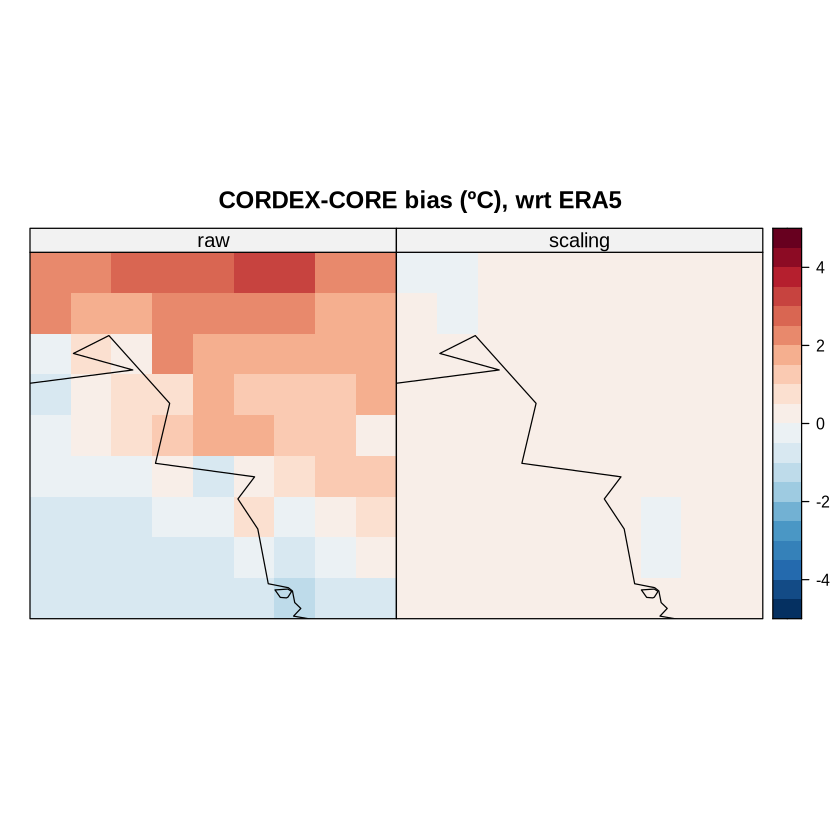

In [12]:
## mean bias ##
bias = gridArithmetics(climatology(cordex), climatology(era5), 
                       operator = "-")
bias.bc.scaling = gridArithmetics(climatology(cordex.bc.scaling), climatology(era5), 
                       operator = "-")
spatialPlot(makeMultiGrid(bias, bias.bc.scaling), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "CORDEX-CORE bias (ºC), wrt ERA5",
            names.attr = c("raw", "scaling"),
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -5, set.max = 5, at = seq(-5, 5, 0.5))

[2026-07-17 11:11:56.251889] Computing member 1 out of 1

[2026-07-17 11:11:56.369184] Done.

[2026-07-17 11:11:56.41947] Computing member 1 out of 1

[2026-07-17 11:11:56.543396] Done.



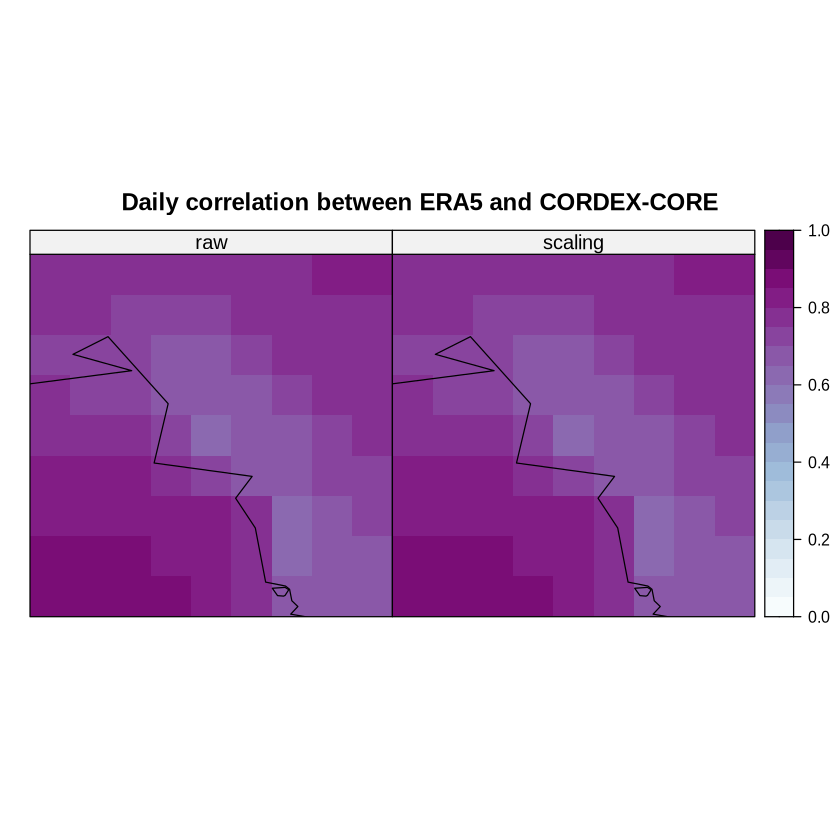

In [13]:
## daily correlation ##
rho = valueMeasure(era5, cordex, measure.code = "ts.rp")
rho.bc.scaling = valueMeasure(era5, cordex.bc.scaling, measure.code = "ts.rp")

spatialPlot(makeMultiGrid(rho$Measure, rho.bc.scaling$Measure), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Daily correlation between ERA5 and CORDEX-CORE",
            names.attr = c("raw", "scaling"),
            color.theme = "BuPu",
            set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

[2026-07-17 11:12:00.206292] Computing member 1 out of 1

[2026-07-17 11:12:00.434051] Done.

[2026-07-17 11:12:00.463795] Computing member 1 out of 1

[2026-07-17 11:12:01.013301] Done.



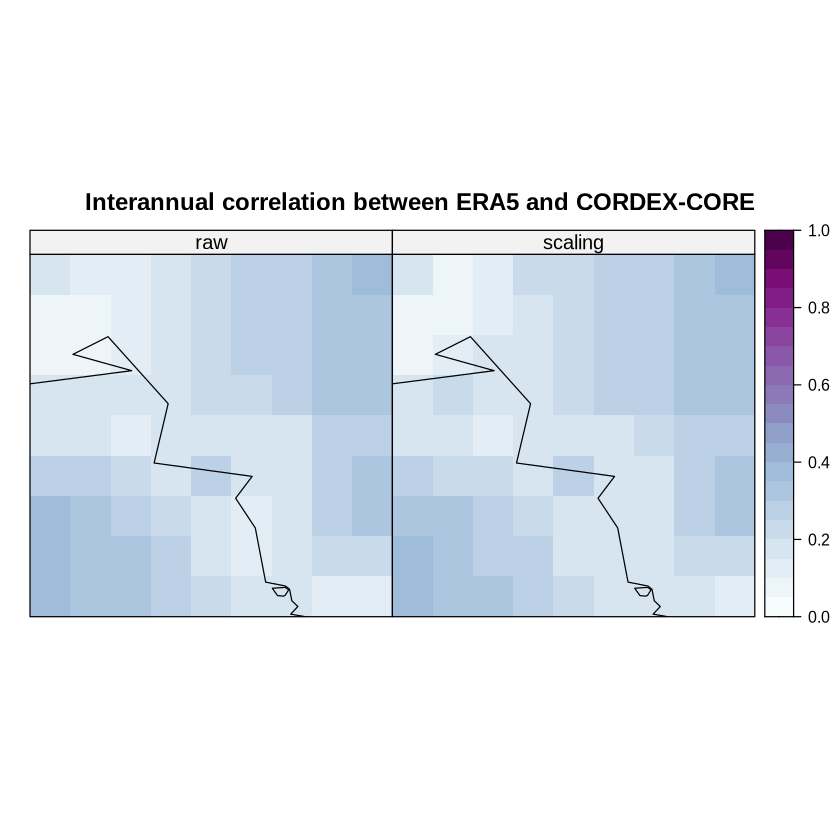

In [14]:
## interannual correlation ##
rho.y = valueMeasure(era5, cordex, measure.code = "ts.rpY")
rho.y.bc.scaling = valueMeasure(era5, cordex.bc.scaling, measure.code = "ts.rpY")

spatialPlot(makeMultiGrid(rho.y$Measure, rho.y.bc.scaling$Measure), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Interannual correlation between ERA5 and CORDEX-CORE",
            names.attr = c("raw", "scaling"),
            color.theme = "BuPu",
            set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

[2026-07-17 11:12:04.061399] - Computing climatology...

[2026-07-17 11:12:04.077682] - Done.



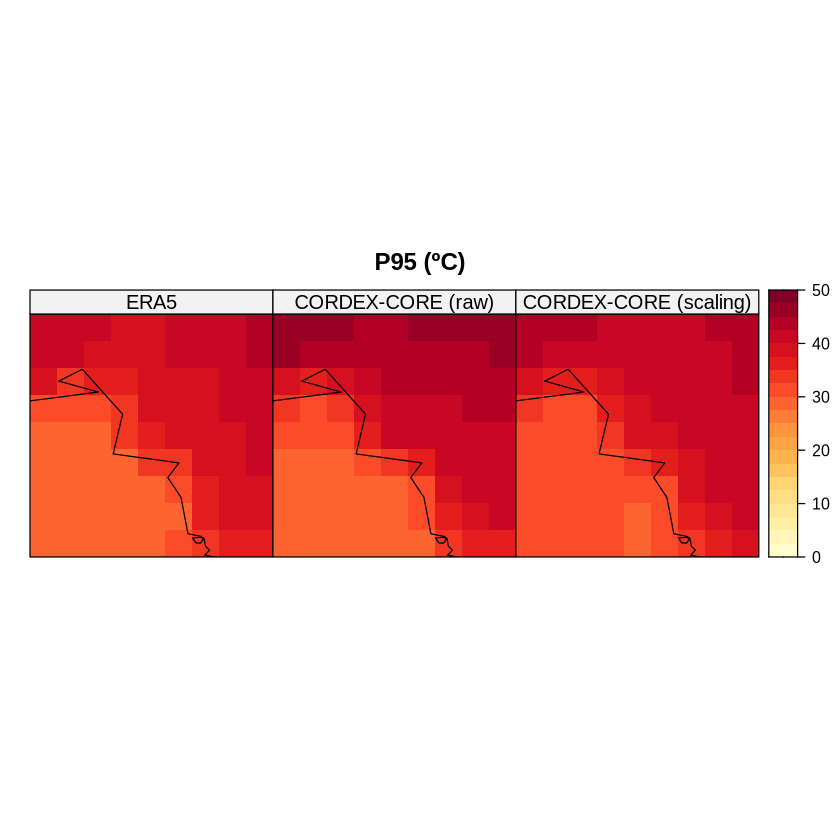

In [15]:
#################
## bias in P95 ##
#################

## computing (and plotting) P95 ##
p95.cordex.bc.scaling = climatology(cordex.bc.scaling, 
                                    clim.fun = list(FUN = "quantile", probs = 0.95, na.rm = TRUE))

spatialPlot(makeMultiGrid(p95.era5, p95.cordex, p95.cordex.bc.scaling), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "P95 (ºC)",
            names.attr = c("ERA5", "CORDEX-CORE (raw)", "CORDEX-CORE (scaling)"),
            color.theme = "YlOrRd",
            set.min = 0, set.max = 50, at = seq(0, 50, 2.5))

[2026-07-17 11:12:09.022405] - Computing climatology...

[2026-07-17 11:12:09.024092] - Done.

[2026-07-17 11:12:09.026357] - Computing climatology...

[2026-07-17 11:12:09.027861] - Done.

[2026-07-17 11:12:09.032102] - Computing climatology...

[2026-07-17 11:12:09.033534] - Done.

[2026-07-17 11:12:09.035096] - Computing climatology...

[2026-07-17 11:12:09.036208] - Done.



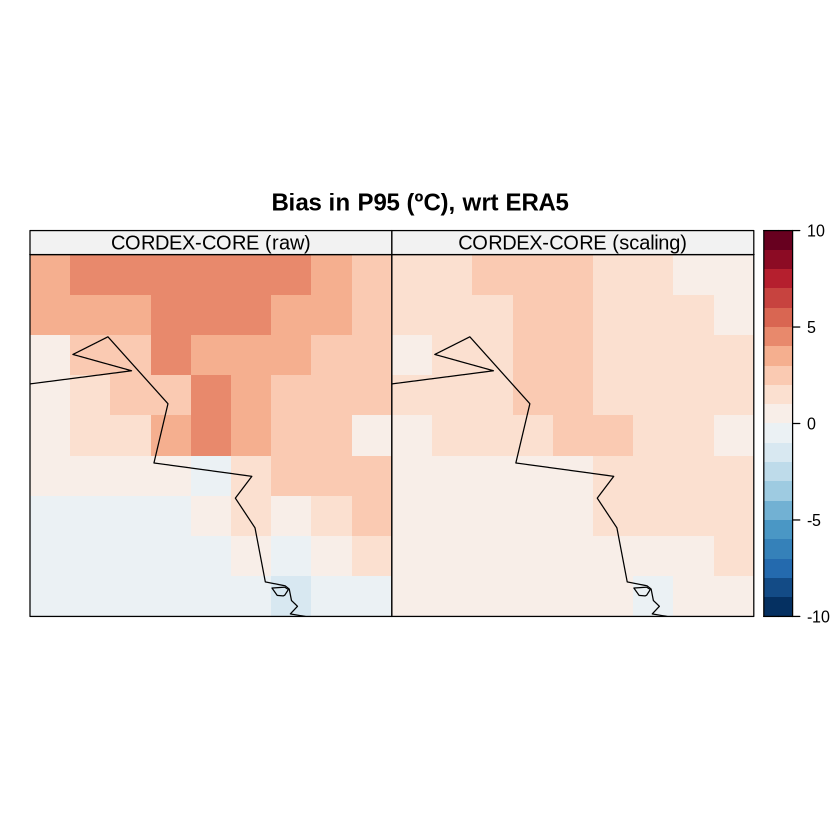

In [16]:
## computing (and plotting) biases for P95 ##
bias.p95.cordex = gridArithmetics(climatology(p95.cordex), climatology(p95.era5), 
                                  operator = "-")
bias.p95.cordex.bc.scaling = gridArithmetics(climatology(p95.cordex.bc.scaling), climatology(p95.era5), 
                                  operator = "-")
spatialPlot(makeMultiGrid(bias.p95.cordex, bias.p95.cordex.bc.scaling),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Bias in P95 (ºC), wrt ERA5",
            names.attr = c("CORDEX-CORE (raw)", "CORDEX-CORE (scaling)"),
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -10, set.max = 10, at = seq(-10, 10, 1))

### 6.2 The Empirical Quantile Mapping (EQM) Method
The second bias correction technique explored in this notebook is Empirical Quantile Mapping (EQM).

Unlike Scaling, EQM does not simply adjust the mean value. Instead, it compares the empirical cumulative distribution functions of the reference dataset and the model simulation during the calibration period. For each simulated value, the method identifies its corresponding percentile in the model distribution and then replaces it with the value associated with the same percentile in the reference distribution. As a result, the corrected simulation reproduces not only the observed mean but also the observed variability and much of the distributional shape.

Because of its flexibility, EQM has become one of the most widely used bias adjustment methods in climate science.

In [17]:
## application of the EQM method for bias correction ##
cordex.bc.eqm = biasCorrection(era5, cordex, method = "eqm", 
                                   cross.val = "kfold", folds = 2)
cordex.bc.eqm$Dates$start = as.character(cordex.bc.eqm$Dates$start)  # manually fixing bug with dates after bias correction
cordex.bc.eqm$Dates$end = as.character(cordex.bc.eqm$Dates$end)  # manually fixing bug with dates after bias correction

getShape(cordex.bc.eqm)
cordex.bc.eqm = intersectGrid(era5, cordex.bc.eqm, type = "temporal", which.return = 2)  # alligning dates after bias correction

[2026-07-17 11:12:12.629389] Trying to determine the time zone...

[2026-07-17 11:12:12.630884] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:12:13.620842] Trying to determine the time zone...

[2026-07-17 11:12:13.622522] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:12:13.744672] Trying to determine the time zone...

[2026-07-17 11:12:13.746429] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-07-17 11:12:14.263358] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:12:14.318192] Number of windows considered: 1...

[2026-07-17 11:12:14.32456] Bias-correcting 1 members separately...

[2026-07-17 11:12:15.24479] Done.

Validation 2, 0 remaining

[2026-07-17 11:12:15.368776] Argument precipitation is set as FALSE, please ensure that this matches your 

time  lat  lon 
7304    9    9

Once EQM has been applied, the same validation diagnostics considered to evaluate the performance of the Scaling method are computed again. Note that, maintaining an identical evaluation framework allows the relative performance of the two methods to be compared directly.

[2026-07-17 11:12:16.698478] - Computing climatology...

[2026-07-17 11:12:16.704643] - Done.

[2026-07-17 11:12:16.708161] - Computing climatology...

[2026-07-17 11:12:16.71383] - Done.

[2026-07-17 11:12:16.721962] - Computing climatology...

[2026-07-17 11:12:16.727707] - Done.

[2026-07-17 11:12:16.730734] - Computing climatology...

[2026-07-17 11:12:16.736352] - Done.

[2026-07-17 11:12:16.74453] - Computing climatology...

[2026-07-17 11:12:16.750284] - Done.

[2026-07-17 11:12:16.753265] - Computing climatology...

[2026-07-17 11:12:16.762412] - Done.



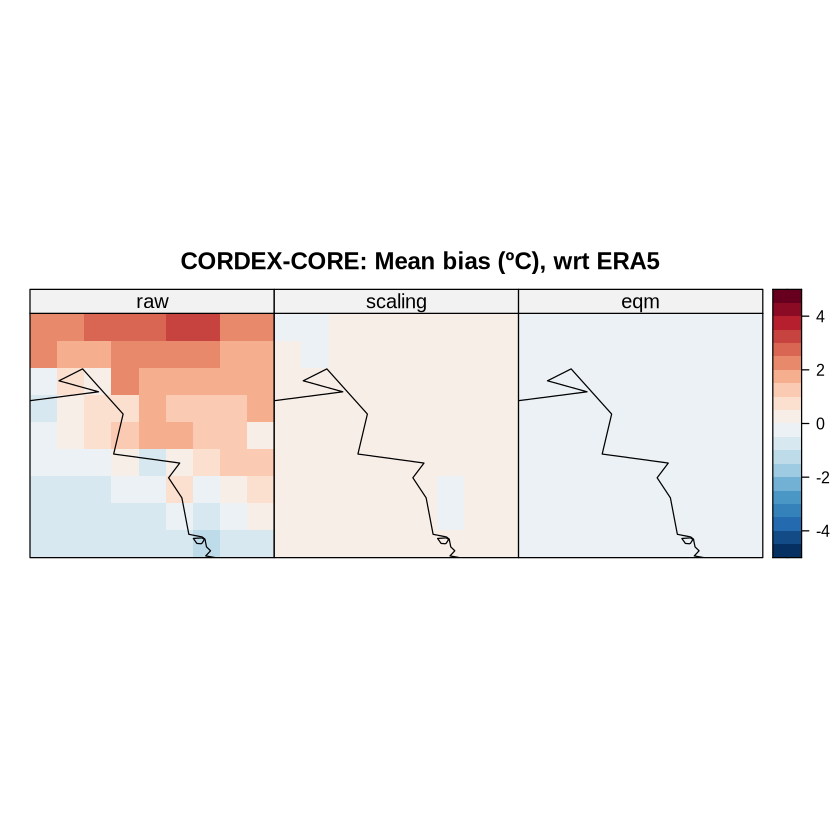

In [18]:
## mean bias ##
bias = gridArithmetics(climatology(cordex), climatology(era5), 
                       operator = "-")
bias.bc.scaling = gridArithmetics(climatology(cordex.bc.scaling), climatology(era5), 
                       operator = "-")
bias.bc.eqm = gridArithmetics(climatology(cordex.bc.eqm), climatology(era5), 
                       operator = "-")
spatialPlot(makeMultiGrid(bias, bias.bc.scaling, bias.bc.eqm), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "CORDEX-CORE: Mean bias (ºC), wrt ERA5",
            names.attr = c("raw", "scaling", "eqm"),
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -5, set.max = 5, at = seq(-5, 5, 0.5))

[2026-07-17 11:12:21.91193] Computing member 1 out of 1

[2026-07-17 11:12:22.026109] Done.

[2026-07-17 11:12:22.481728] Computing member 1 out of 1

[2026-07-17 11:12:22.582193] Done.

[2026-07-17 11:12:22.810076] Computing member 1 out of 1

[2026-07-17 11:12:22.91261] Done.



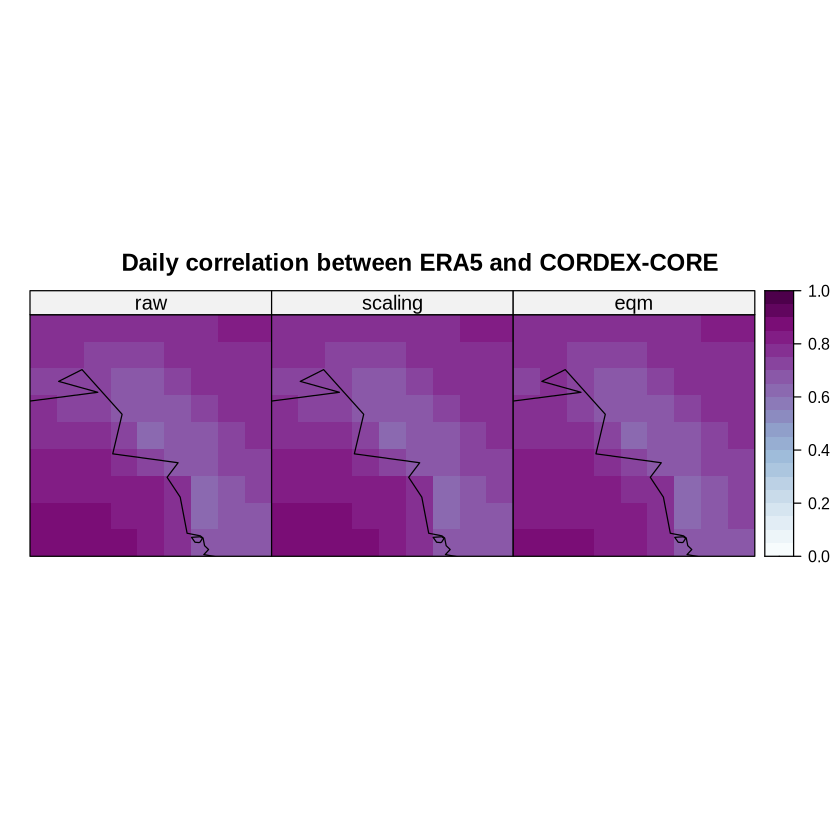

In [19]:
## daily correlation ##
rho = valueMeasure(era5, cordex, measure.code = "ts.rp")
rho.bc.scaling = valueMeasure(era5, cordex.bc.scaling, measure.code = "ts.rp")
rho.bc.eqm = valueMeasure(era5, cordex.bc.eqm, measure.code = "ts.rp")

spatialPlot(makeMultiGrid(rho$Measure, rho.bc.scaling$Measure, rho.bc.eqm$Measure), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Daily correlation between ERA5 and CORDEX-CORE",
            names.attr = c("raw", "scaling", "eqm"),
            color.theme = "BuPu",
            set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

[2026-07-17 11:12:27.689586] Computing member 1 out of 1

[2026-07-17 11:12:28.363177] Done.

[2026-07-17 11:12:28.39008] Computing member 1 out of 1

[2026-07-17 11:12:28.610744] Done.

[2026-07-17 11:12:28.864942] Computing member 1 out of 1

[2026-07-17 11:12:29.050011] Done.



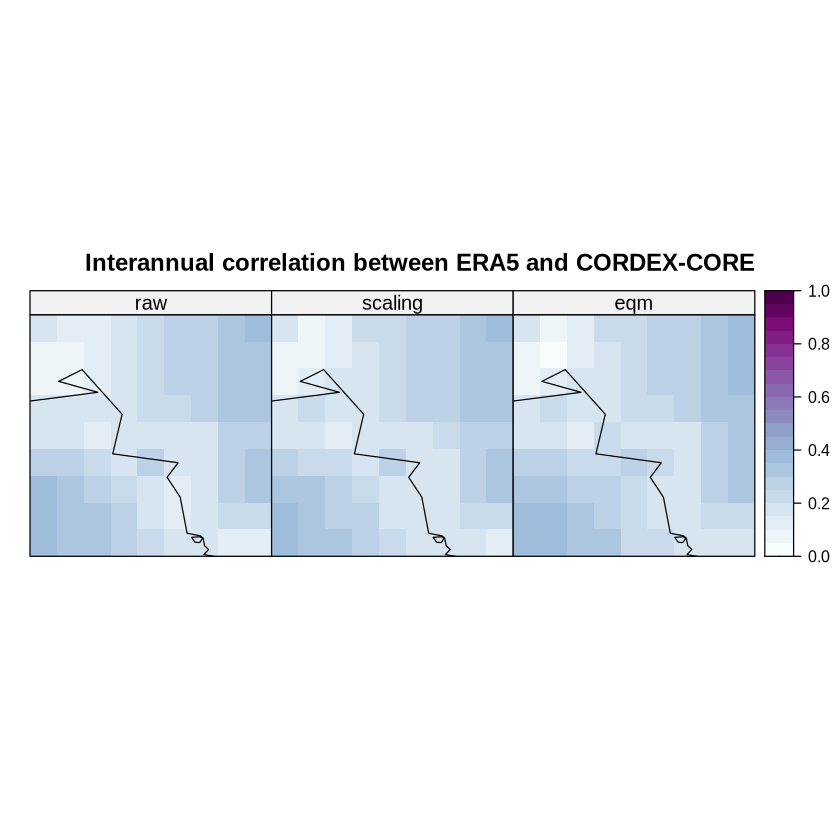

In [20]:
## interannual correlation ##
rho.y = valueMeasure(era5, cordex, measure.code = "ts.rpY")
rho.y.bc.scaling = valueMeasure(era5, cordex.bc.scaling, measure.code = "ts.rpY")
rho.y.bc.eqm = valueMeasure(era5, cordex.bc.eqm, measure.code = "ts.rpY")

spatialPlot(makeMultiGrid(rho.y$Measure, rho.y.bc.scaling$Measure, rho.y.bc.eqm$Measure), 
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "Interannual correlation between ERA5 and CORDEX-CORE",
            names.attr = c("raw", "scaling", "eqm"),
            color.theme = "BuPu",
            set.min = 0, set.max = 1, at = seq(0, 1, 0.05))

[2026-07-17 11:12:33.770124] - Computing climatology...

[2026-07-17 11:12:33.787364] - Done.

[2026-07-17 11:12:33.790117] - Computing climatology...

[2026-07-17 11:12:33.791385] - Done.

[2026-07-17 11:12:33.793194] - Computing climatology...

[2026-07-17 11:12:33.794355] - Done.



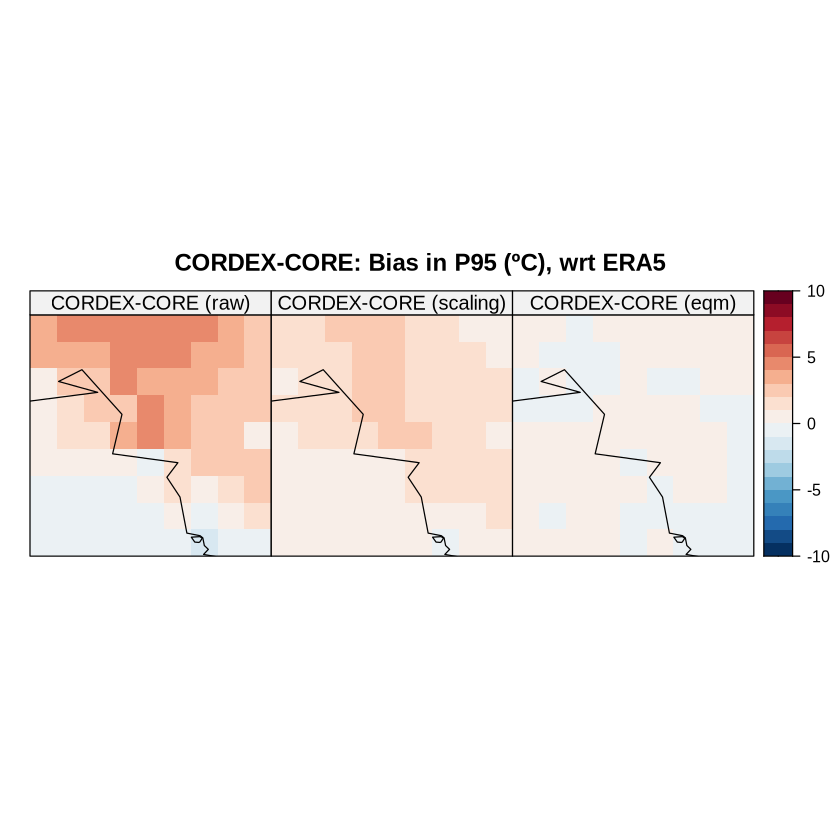

In [21]:
## bias in P95 ##
p95.cordex.bc.eqm = climatology(cordex.bc.eqm, 
                                    clim.fun = list(FUN = "quantile", probs = 0.95, na.rm = TRUE))
bias.p95.cordex.bc.eqm = gridArithmetics(climatology(p95.cordex.bc.eqm), climatology(p95.era5), 
                                             operator = "-")
spatialPlot(makeMultiGrid(bias.p95.cordex, bias.p95.cordex.bc.scaling, bias.p95.cordex.bc.eqm),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(3, 1),
            main = "CORDEX-CORE: Bias in P95 (ºC), wrt ERA5",
            names.attr = c("CORDEX-CORE (raw)", "CORDEX-CORE (scaling)", "CORDEX-CORE (eqm)"),
            color.theme = "RdBu", rev.colors = TRUE,
            set.min = -10, set.max = 10, at = seq(-10, 10, 1))

## 7. Climate Indices

Many climate impact studies do not analyse climatic variables (e.g. temperature, precipitation, etc.) directly.

Instead, they focus on climate indices, i.e. variables derived from the original meteorological observations that describe phenomena of practical interest.

Some examples are:

* the number of frost days;
* the number of tropical nights;
* the number and duration of heat waves;
* the number of rainy days;
* etc.
  
Climate indices often provide a much more direct connection between climate and societal impacts than raw meteorological variables.

In this notebook, we investigate a commonly used temperature-derived indicator: the number of days per year with maximum temperature above 35ºC (ND35). The function `binaryGrid()` is used to compute it.

Note that, threshold-based indices are widely used because they are easy to interpret and often correspond directly to impact-relevant conditions.

For example,

* agricultural productivity
* livestock heat stress
* electricity demand
* human thermal comfort

may all depend on the number of days exceeding particular temperature thresholds.

**Note:** Unlike percentile-based indices, threshold indices are especially sensitive to systematic biases. Even a relatively small temperature bias can produce large differences in the number of exceedances. This explains why bias correction has become standard practice in sectors such as agriculture and human health.

In [22]:
########################################################################################################
## computing (and comparing) ND35 for ERA5 and CORDEX-CORE (raw, scaling-corrected and EQM-corrected) ##
########################################################################################################

## computing ND35 ##
nd35.era5 = climatology(aggregateGrid(binaryGrid(era5, condition = "GE", threshold = 35),
              aggr.y = list(FUN = "sum")))  
nd35.cordex = climatology(aggregateGrid(binaryGrid(cordex, condition = "GE", threshold = 35),
                                      aggr.y = list(FUN = "sum")))  
nd35.cordex.bc.scaling = climatology(aggregateGrid(binaryGrid(cordex.bc.scaling, condition = "GE", threshold = 35),
                                        aggr.y = list(FUN = "sum")))  
nd35.cordex.bc.eqm = climatology(aggregateGrid(binaryGrid(cordex.bc.eqm, condition = "GE", threshold = 35),
                                        aggr.y = list(FUN = "sum"))) 

[2026-07-17 11:12:39.507369] Performing annual aggregation...

[2026-07-17 11:12:39.525794] Done.

[2026-07-17 11:12:39.529073] - Computing climatology...

[2026-07-17 11:12:39.530789] - Done.

[2026-07-17 11:12:39.854443] Performing annual aggregation...

[2026-07-17 11:12:39.873056] Done.

[2026-07-17 11:12:39.876455] - Computing climatology...

[2026-07-17 11:12:39.878281] - Done.

[2026-07-17 11:12:40.871849] Performing annual aggregation...

[2026-07-17 11:12:40.892314] Done.

[2026-07-17 11:12:40.895279] - Computing climatology...

[2026-07-17 11:12:40.896674] - Done.

[2026-07-17 11:12:41.194387] Performing annual aggregation...

[2026-07-17 11:12:41.21465] Done.

[2026-07-17 11:12:41.217621] - Computing climatology...

[2026-07-17 11:12:41.218951] - Done.



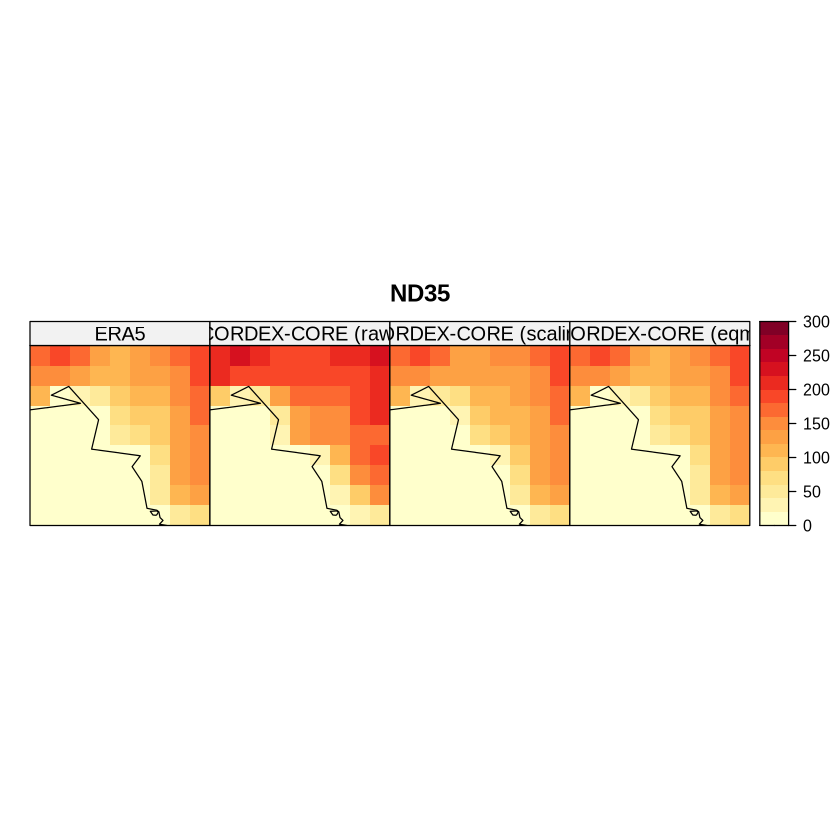

In [23]:
## plotting ##
spatialPlot(makeMultiGrid(nd35.era5, nd35.cordex, nd35.cordex.bc.scaling, nd35.cordex.bc.eqm), 
            backdrop.theme = "countries",
            main = "ND35",
            as.table = TRUE,
            layout = c(4, 1),
            names.attr = c("ERA5", "CORDEX-CORE (raw)", 
                           "CORDEX-CORE (scaling)", "CORDEX-CORE (eqm)"),
            color.them = "YlOrRd",
            set.min = 0, set.max = 300, at = seq(0, 300, 20))

## 8. From Spatial to Local Validation

So far, the evaluation has focused primarily on spatial diagnostics. Maps are very useful because they provide an overview of model performance across the entire study domain.

However, many climate impact studies are ultimately conducted at specific locations. Farmers, water managers and urban planners are usually interested in the climate conditions at individual sites. For this reason, we now shift our attention from the spatial domain to the analysis of a single location.

This change of perspective allows us to investigate aspects of model performance that are difficult to appreciate from maps alone, including the detailed temporal evolution and the complete statistical distribution of the simulated temperatures.

The station considered for this analysis is Karachi Airport, one of the best-known meteorological stations in Pakistan. The station is retrieved through its metadata rather than by its numerical position within the dataset.

In [24]:
## Karachi (airport) ##
lon.karachi = 67.133 
lat.karachi = 24.9

era5.karachi = subsetGrid(era5, lonLim = lon.karachi, latLim = lat.karachi)
cordex.karachi = subsetGrid(cordex, lonLim = lon.karachi, latLim = lat.karachi)
cordex.bc.scaling.karachi = subsetGrid(cordex.bc.scaling, lonLim = lon.karachi, latLim = lat.karachi)
cordex.bc.eqm.karachi = subsetGrid(cordex.bc.eqm, lonLim = lon.karachi, latLim = lat.karachi)

First, we produce q-q plots for comparing the daily observed records against ERA5, the raw and the bias-corrected (both using the scaling and the EQM methods) CORDEX-CORE simulations at Karachi (airport).

null device 
          1

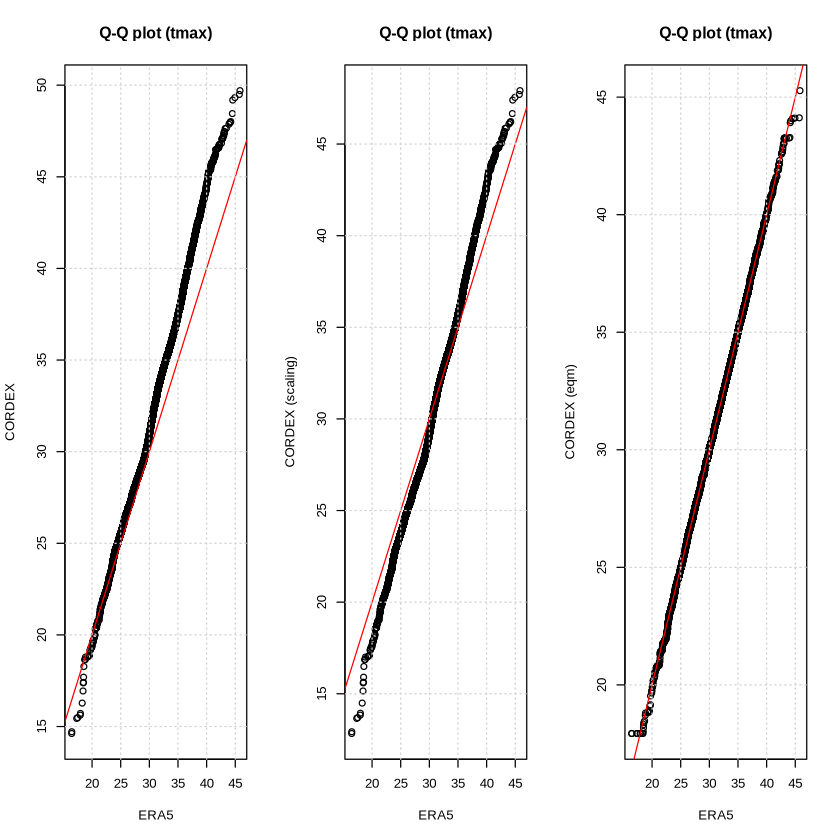

In [25]:
## q-q plots, for karachi ##
par(mfrow = c(1, 3))
qqplot(era5.karachi$Data, cordex.karachi$Data, 
              main = "Q-Q plot (tmax)",
              xlab = "ERA5", ylab = "CORDEX"); abline(0, 1, col = "red"); grid()
qqplot(era5.karachi$Data, cordex.bc.scaling.karachi$Data, 
              main = "Q-Q plot (tmax)",
              xlab = "ERA5", ylab = "CORDEX (scaling)"); abline(0, 1, col = "red"); grid()
qqplot(era5.karachi$Data, cordex.bc.eqm.karachi$Data, 
              main = "Q-Q plot (tmax)",
              xlab = "ERA5", ylab = "CORDEX (eqm)"); abline(0, 1, col = "red"); grid()
dev.off()

Second, we compare the PDF derived from daily observed records against those corresponding to ERA5, the raw and the bias-corrected (both using the scaling and the EQM methods) CORDEX-CORE simulations at Karachi (airport).

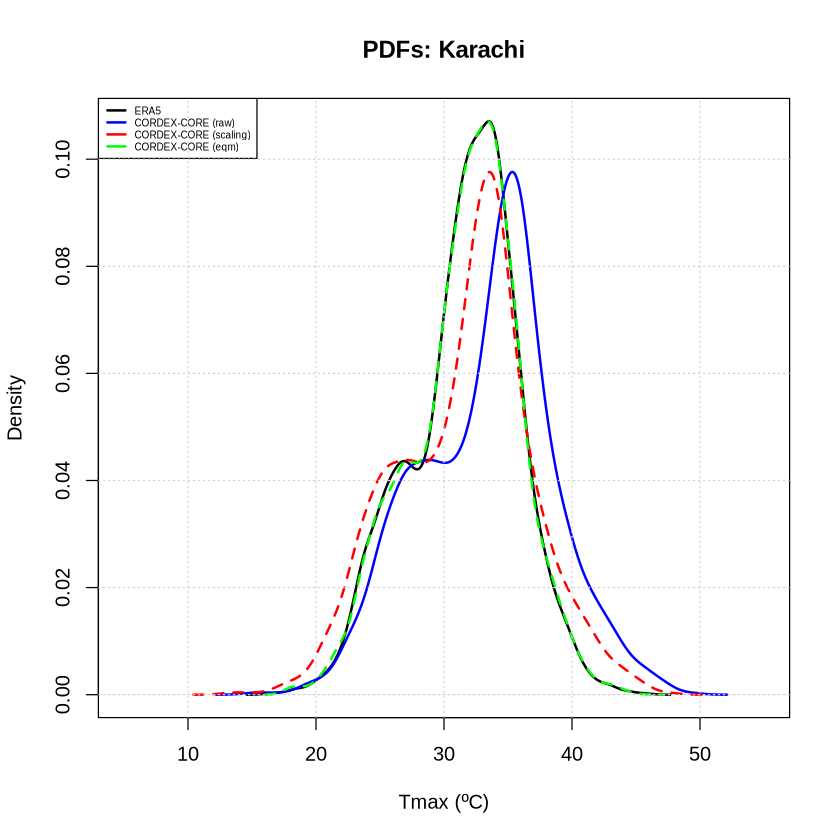

In [26]:
## PDFs
pdf.era5.karachi = density(era5.karachi$Data)
pdf.cordex.karachi = density(cordex.karachi$Data)
pdf.cordex.bc.scaling.karachi = density(cordex.bc.scaling.karachi$Data, na.rm = TRUE)
pdf.cordex.bc.eqm.karachi = density(cordex.bc.eqm.karachi$Data, na.rm = TRUE)

plot(pdf.era5.karachi, col = "black", lwd = 2,
     main = "PDFs: Karachi",
     xlab = "Tmax (ºC)", ylab = "Density",
     xlim = c(5, 55))
lines(pdf.cordex.karachi, col = "blue", lwd = 2)
lines(pdf.cordex.bc.scaling.karachi, col = "red", lwd = 2, lty = 2)
lines(pdf.cordex.bc.eqm.karachi, col = "green", lwd = 2, lty = 2)
legend("topleft", 
       legend = c("ERA5", "CORDEX-CORE (raw)", "CORDEX-CORE (scaling)", "CORDEX-CORE (eqm)"),
       col = c("black", "blue", "red", "green"),
       lwd = 2,
       cex = 0.5)
grid()

Finally, we compute and visualize the ND35 for ERA5, the raw and the bias-corrected (both using the scaling and the EQM methods) CORDEX-CORE simulations at Karachi (airport).

[2026-07-17 11:12:48.83492] Performing annual aggregation...

[2026-07-17 11:12:48.836709] Done.

[2026-07-17 11:12:49.063273] Performing annual aggregation...

[2026-07-17 11:12:49.064974] Done.

[2026-07-17 11:12:49.341543] Performing annual aggregation...

[2026-07-17 11:12:49.356971] Done.

[2026-07-17 11:12:49.728019] Performing annual aggregation...

[2026-07-17 11:12:49.745431] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



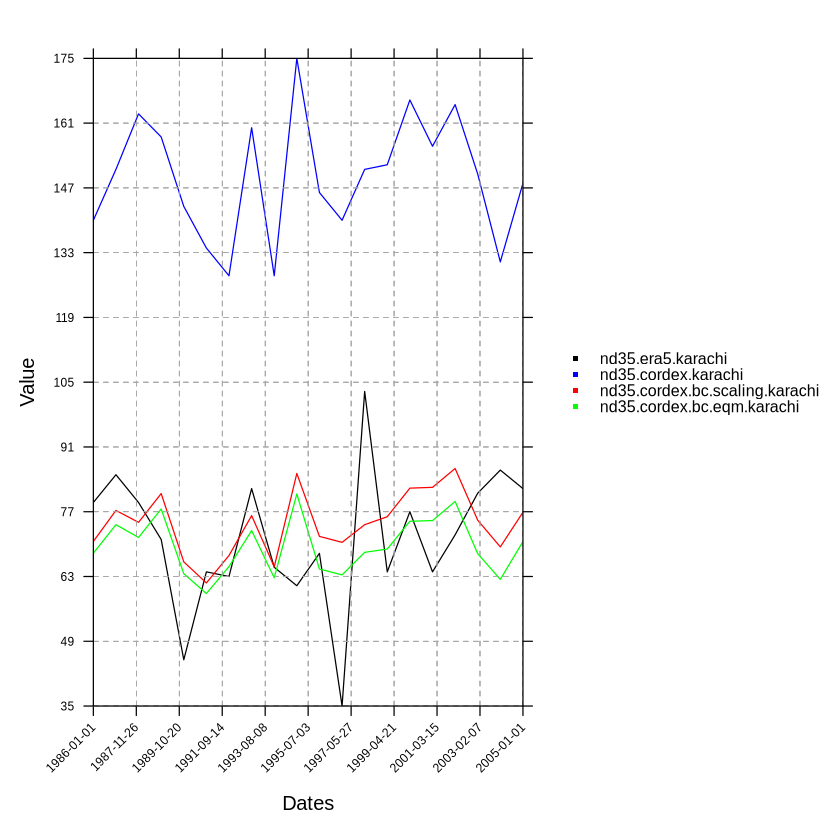

In [27]:
## ND35, for karachi ##
nd35.era5.karachi = aggregateGrid(binaryGrid(era5.karachi, condition = "GE", threshold = 35),
              aggr.y = list(FUN = "sum"))
nd35.cordex.karachi = aggregateGrid(binaryGrid(cordex.karachi, condition = "GE", threshold = 35),
                                  aggr.y = list(FUN = "sum"))
nd35.cordex.bc.scaling.karachi = aggregateGrid(binaryGrid(cordex.bc.scaling, condition = "GE", threshold = 35),
                                    aggr.y = list(FUN = "sum"))
nd35.cordex.bc.eqm.karachi = aggregateGrid(binaryGrid(cordex.bc.eqm, condition = "GE", threshold = 35),
                                               aggr.y = list(FUN = "sum"))

## plotting time series ##
temporalPlot(nd35.era5.karachi, nd35.cordex.karachi, 
            nd35.cordex.bc.scaling.karachi,
            nd35.cordex.bc.eqm.karachi,
            cols = c("black", "blue", "red", "green"))